<a href="https://colab.research.google.com/github/brunolmars/PI-I-Ciencia-da-Computacao/blob/main/database/Data_Forms.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [160]:
import pandas as pd
from google.colab import drive
from IPython.display import display

drive.mount('/content/drive')

NOME_ARQUIVO_FORM = '/content/drive/MyDrive/respostas_formulario.csv'

def extrair_dados_form(nome_arquivo):
    """Carrega o arquivo CSV do Google Form."""
    try:
        df_bruto = pd.read_csv(nome_arquivo, sep=',', encoding='utf-8')

        print(f"\nSucesso! {len(df_bruto)} respostas encontradas no arquivo.")
        return df_bruto

    except FileNotFoundError:
        print(f"\nERRO DE EXTRAÇÃO: Arquivo '{nome_arquivo}' não encontrado.")
        print("Certifique-se de que o caminho acima está EXATO (incluindo letras maiúsculas/minúsculas da pasta).")
        return pd.DataFrame()
    except Exception as e:
        print(f"\nERRO DE LEITURA: Não foi possível ler o arquivo. Erro: {e}")
        return pd.DataFrame()


df_bruto = extrair_dados_form(NOME_ARQUIVO_FORM)

if not df_bruto.empty:
    print("\n✅ DataFrame Bruto carregado na variável 'df_bruto'.")
    print("Use os nomes das colunas abaixo para renomeá-las na Célula 2.")
    display(df_bruto.head())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

Sucesso! 137 respostas encontradas no arquivo.

✅ DataFrame Bruto carregado na variável 'df_bruto'.
Use os nomes das colunas abaixo para renomeá-las na Célula 2.


,Faixa etária,Participa de apostas,Reserva financeira,Resgate imediato,Poupança,Tesouro Nacional,Renda fixa,Renda variável,Reserva de valor,Nível de conhecimento,Objetivo financeiro,Decisão financeira,Jornada financeira (opcional),Conselho financeiro (opcional),E-mail (opcional)
0,41-60,"Sim, com frequência, e às vezes sinto dificuld...",Não,Não,Sim,Não tenho conhecimento sobre esse tipo de inve...,Não,Não tenho conhecimento sobre esse tipo de inve...,Sim,Avançado,Construir patrimônio,"Prefiro decisões seguras, mesmo que o retorno ...",Aprendi que cada pequena economia faz diferença.,NaN,maria.oliveira@gmail.com
1,41-60,Não participo desse tipo de jogo,Sim,Não possuo a reserva,Não,Sim,Não,Não tenho conhecimento sobre esse tipo de inve...,Não,Avançado,Construir patrimônio,"Prefiro decisões seguras, mesmo que o retorno ...",NaN,NaN,NaN
2,26 - 40,Não participo desse tipo de jogo,Não,Sim,Não,Não,Não,Sim,Não tenho conhecimento sobre esse tipo de inve...,Iniciante,Juntar dinheiro para uma meta de curto prazo (...,Estou disposto(a) a aprender e assumir novas e...,NaN,"Comece a poupar cedo, mesmo que seja pouco.",joao.silva@gmail.com
3,18 - 25,Não participo desse tipo de jogo,Não,Sim,Sim,Sim,Sim,Não,Não,Intermediário,Viver de renda,"Prefiro decisões seguras, mesmo que o retorno ...",NaN,NaN,NaN
4,60+,Não participo desse tipo de jogo,Não,Sim,Não tenho conhecimento sobre esse tipo de inve...,Não,Não,Não,Sim,Intermediário,Viver de renda,Busco equilibrar segurança e rentabilidade,NaN,Equilibre segurança e rentabilidade nos invest...,NaN


In [161]:
# Rename das colunas
df_limpo.rename(columns={
    'Nível de conhecimento': 'nivel_conhecimento',
    'Poupança': 'poupanca',
    'Tesouro Nacional': 'tesouro',
    'Renda fixa': 'renda_fixa',
    'Renda variável': 'renda_variavel',
    'Objetivo financeiro': 'objetivo_financeiro',
    'Decisão financeira': 'decisao_financeira',
    'Jornada financeira (opcional)': 'jornada_financeira',
    'Participa de apostas': 'participa_apostas',
    'Reserva financeira': 'reserva_financeira'
}, inplace=True)

# Limpeza e padronização
df_limpo['faixa_etaria'] = df_limpo['faixa_etaria'].str.strip()
df_limpo['nivel_conhecimento'] = df_limpo['nivel_conhecimento'].str.strip().str.title()
df_limpo['reserva_financeira'] = df_limpo['reserva_financeira'].str.strip().str.title()
df_limpo['participa_apostas'] = df_limpo['participa_apostas'].str.strip().str.title()  # <-- nome correto


In [162]:

df_limpo = df_bruto.rename(columns={
    'Faixa etária': 'faixa_etaria',
    'Participa de apostas': 'participa_apostas',
    'Reserva financeira': 'reserva_financeira',
    'Resgate imediato': 'resgate_imediato',
    'Poupança': 'poupanca',
    'Tesouro Nacional': 'tesouro',
    'Renda fixa': 'renda_fixa',
    'Renda variável': 'renda_variavel',
    'Reserva de valor': 'reserva_valor',
    'Nível de conhecimento': 'nivel_conhecimento',
    'Objetivo financeiro': 'objetivo_financeiro',
    'Decisão financeira': 'decisao_financeira',
    'Jornada financeira (opcional)': 'jornada_financeira',
    'Conselho financeiro (opcional)': 'conselho_financeiro',
    'E-mail (opcional)': 'email'
}, inplace=False)


for col in ['poupanca','tesouro','renda_fixa','renda_variavel','reserva_valor']:
    if col in df_limpo.columns:
        df_limpo[col] = df_limpo[col].astype(str).str.strip().apply(lambda x: 'Sim' if 'Sim' in x else 'Não')

df_limpo.head()


,faixa_etaria,participa_apostas,reserva_financeira,resgate_imediato,poupanca,tesouro,renda_fixa,renda_variavel,reserva_valor,nivel_conhecimento,objetivo_financeiro,decisao_financeira,jornada_financeira,conselho_financeiro,email
0,41-60,"Sim, com frequência, e às vezes sinto dificuld...",Não,Não,Sim,Não,Não,Não,Sim,Avançado,Construir patrimônio,"Prefiro decisões seguras, mesmo que o retorno ...",Aprendi que cada pequena economia faz diferença.,NaN,maria.oliveira@gmail.com
1,41-60,Não participo desse tipo de jogo,Sim,Não possuo a reserva,Não,Sim,Não,Não,Não,Avançado,Construir patrimônio,"Prefiro decisões seguras, mesmo que o retorno ...",NaN,NaN,NaN
2,26 - 40,Não participo desse tipo de jogo,Não,Sim,Não,Não,Não,Sim,Não,Iniciante,Juntar dinheiro para uma meta de curto prazo (...,Estou disposto(a) a aprender e assumir novas e...,NaN,"Comece a poupar cedo, mesmo que seja pouco.",joao.silva@gmail.com
3,18 - 25,Não participo desse tipo de jogo,Não,Sim,Sim,Sim,Sim,Não,Não,Intermediário,Viver de renda,"Prefiro decisões seguras, mesmo que o retorno ...",NaN,NaN,NaN
4,60+,Não participo desse tipo de jogo,Não,Sim,Não,Não,Não,Não,Sim,Intermediário,Viver de renda,Busco equilibrar segurança e rentabilidade,NaN,Equilibre segurança e rentabilidade nos invest...,NaN


In [163]:
tabela_investimentos = df_limpo.groupby('nivel_conhecimento').agg(
    Poupanca=('poupanca', lambda x: (x=='Sim').sum()),
    Tesouro=('tesouro', lambda x: (x=='Sim').sum()),
    Renda_Fixa=('renda_fixa', lambda x: (x=='Sim').sum()),
    Renda_Variavel=('renda_variavel', lambda x: (x=='Sim').sum()),
    Reserva_Valor=('reserva_valor', lambda x: (x=='Sim').sum())
).reset_index()

tabela_investimentos


,nivel_conhecimento,Poupanca,Tesouro,Renda_Fixa,Renda_Variavel,Reserva_Valor
0,Avançado,14,18,17,14,20
1,Iniciante,11,18,15,16,12
2,Intermediário,10,16,15,16,10


In [164]:
tabela_faixa = df_limpo.groupby(['faixa_etaria','nivel_conhecimento']).size().reset_index(name='quantidade')
tabela_faixa


,faixa_etaria,nivel_conhecimento,quantidade
0,18 - 25,Avançado,16
1,18 - 25,Iniciante,9
2,18 - 25,Intermediário,12
3,26 - 40,Avançado,9
4,26 - 40,Iniciante,15
5,26 - 40,Intermediário,7
6,41-60,Avançado,13
7,41-60,Iniciante,10
8,41-60,Intermediário,9
9,60+,Avançado,16


In [165]:
tabela_objetivo = df_limpo.groupby(['nivel_conhecimento','objetivo_financeiro']).size().reset_index(name='quantidade')
tabela_objetivo


,nivel_conhecimento,objetivo_financeiro,quantidade
0,Avançado,Comprar uma casa,13
1,Avançado,Construir patrimônio,17
2,Avançado,Juntar dinheiro para uma meta de curto prazo (...,12
3,Avançado,Viver de renda,12
4,Iniciante,Comprar uma casa,15
5,Iniciante,Construir patrimônio,5
6,Iniciante,Juntar dinheiro para uma meta de curto prazo (...,16
7,Iniciante,Viver de renda,11
8,Intermediário,Comprar uma casa,7
9,Intermediário,Construir patrimônio,8


In [166]:
tabela_decisao = df_limpo.groupby(['nivel_conhecimento','decisao_financeira']).size().reset_index(name='quantidade')
tabela_decisao


,nivel_conhecimento,decisao_financeira,quantidade
0,Avançado,Busco equilibrar segurança e rentabilidade,15
1,Avançado,Estou disposto(a) a aprender e assumir novas e...,20
2,Avançado,"Prefiro decisões seguras, mesmo que o retorno ...",19
3,Iniciante,Busco equilibrar segurança e rentabilidade,13
4,Iniciante,Estou disposto(a) a aprender e assumir novas e...,18
5,Iniciante,"Prefiro decisões seguras, mesmo que o retorno ...",16
6,Intermediário,Busco equilibrar segurança e rentabilidade,15
7,Intermediário,Estou disposto(a) a aprender e assumir novas e...,9
8,Intermediário,"Prefiro decisões seguras, mesmo que o retorno ...",12


In [167]:
tabela_jornada = df_limpo.groupby(['nivel_conhecimento','jornada_financeira']).size().reset_index(name='quantidade')
tabela_jornada


,nivel_conhecimento,jornada_financeira,quantidade
0,Avançado,Aprendi a importância de poupar cedo.,3
1,Avançado,Aprendi que cada pequena economia faz diferença.,2
2,Avançado,Busco planejar melhor minhas finanças.,1
3,Avançado,Estou aprendendo a equilibrar gastos e investi...,3
4,Avançado,Já me arrependi de gastos impulsivos.,4
5,Avançado,Pretendo criar uma reserva financeira sólida.,3
6,Avançado,Quero construir patrimônio com segurança.,2
7,Avançado,Tenho o sonho de investir em imóveis.,1
8,Iniciante,Aprendi a importância de poupar cedo.,2
9,Iniciante,Aprendi que cada pequena economia faz diferença.,3


In [168]:
df_limpo.rename(columns={
    'Nível de conhecimento': 'nivel_conhecimento',
    'Objetivo financeiro': 'objetivo_financeiro',
    'Decisão financeira': 'decisao_financeira',
    'Jornada financeira (opcional)': 'jornada_financeira'
}, inplace=True)

tabela_comparativa = df_limpo.groupby(
    ['nivel_conhecimento', 'objetivo_financeiro', 'decisao_financeira', 'jornada_financeira']
).size().reset_index(name='quantidade')

tabela_comparativa = tabela_comparativa.sort_values(by='quantidade', ascending=False)
tabela_comparativa


,nivel_conhecimento,objetivo_financeiro,decisao_financeira,jornada_financeira,quantidade
5,Avançado,Construir patrimônio,Estou disposto(a) a aprender e assumir novas e...,Aprendi a importância de poupar cedo.,2
14,Avançado,Juntar dinheiro para uma meta de curto prazo (...,"Prefiro decisões seguras, mesmo que o retorno ...",Pretendo criar uma reserva financeira sólida.,2
1,Avançado,Comprar uma casa,Busco equilibrar segurança e rentabilidade,Aprendi que cada pequena economia faz diferença.,1
2,Avançado,Comprar uma casa,Busco equilibrar segurança e rentabilidade,Já me arrependi de gastos impulsivos.,1
3,Avançado,Comprar uma casa,Busco equilibrar segurança e rentabilidade,Quero construir patrimônio com segurança.,1
0,Avançado,Comprar uma casa,Busco equilibrar segurança e rentabilidade,Aprendi a importância de poupar cedo.,1
4,Avançado,Comprar uma casa,"Prefiro decisões seguras, mesmo que o retorno ...",Quero construir patrimônio com segurança.,1
6,Avançado,Construir patrimônio,Estou disposto(a) a aprender e assumir novas e...,Estou aprendendo a equilibrar gastos e investi...,1
8,Avançado,Construir patrimônio,"Prefiro decisões seguras, mesmo que o retorno ...",Aprendi que cada pequena economia faz diferença.,1
7,Avançado,Construir patrimônio,Estou disposto(a) a aprender e assumir novas e...,Tenho o sonho de investir em imóveis.,1


In [169]:
def valor_mais_frequente(series):
    return series.mode()[0] if not series.mode().empty else None

tabela_resumo = df_limpo.groupby('faixa_etaria').agg(
    total_pessoas=('faixa_etaria', 'count'),
    nivel_conhecimento_mais_comum=('nivel_conhecimento', valor_mais_frequente),
    pessoas_com_reserva=('reserva_financeira', lambda x: (x == 'Sim').sum()),
    pessoas_que_apostam=('participa_apostas', lambda x: (x.str.contains('Sim')).sum())  # <-- nome correto
).reset_index()

tabela_resumo


,faixa_etaria,total_pessoas,nivel_conhecimento_mais_comum,pessoas_com_reserva,pessoas_que_apostam
0,18 - 25,37,Avançado,11,24
1,26 - 40,31,Iniciante,7,16
2,41-60,32,Avançado,13,18
3,60+,37,Avançado,12,20


In [170]:
def valor_mais_frequente(series):
    return series.mode()[0] if not series.mode().empty else None

tabela_completa = df_limpo.groupby('faixa_etaria').agg(
    total_pessoas=('faixa_etaria', 'count'),
    nivel_conhecimento_mais_comum=('nivel_conhecimento', valor_mais_frequente),
    pessoas_com_reserva=('reserva_financeira', lambda x: (x == 'Sim').sum()),
    pessoas_que_apostam=('participa_apostas', lambda x: (x.str.contains('Sim')).sum()),
    poupanca=('poupanca', lambda x: (x == 'Sim').sum()),
    tesouro=('tesouro', lambda x: (x == 'Sim').sum()),
    renda_fixa=('renda_fixa', lambda x: (x == 'Sim').sum()),
    renda_variavel=('renda_variavel', lambda x: (x == 'Sim').sum()),
    objetivo_financeiro_mais_comum=('objetivo_financeiro', valor_mais_frequente)
).reset_index()

tabela_completa


,faixa_etaria,total_pessoas,nivel_conhecimento_mais_comum,pessoas_com_reserva,pessoas_que_apostam,poupanca,tesouro,renda_fixa,renda_variavel,objetivo_financeiro_mais_comum
0,18 - 25,37,Avançado,11,24,9,15,11,8,Viver de renda
1,26 - 40,31,Iniciante,7,16,7,8,11,12,Juntar dinheiro para uma meta de curto prazo (...
2,41-60,32,Avançado,13,18,8,13,13,15,Construir patrimônio
3,60+,37,Avançado,12,20,11,16,12,11,Juntar dinheiro para uma meta de curto prazo (...


In [171]:
# Corrige coluna resgate_imediato se não existir
if 'resgate_imediato' not in df_limpo.columns:
    df_limpo['resgate_imediato'] = df_limpo['Resgate imediato'].str.strip().str.title()

def contar_sim(series):
    return (series == 'Sim').sum()

tabela_comportamental = df_limpo.groupby('faixa_etaria').agg(
    total_pessoas=('faixa_etaria', 'count'),
    pessoas_que_apostam=('participa_apostas', lambda x: x.str.contains('Sim').sum()),  # nome atualizado
    pessoas_com_resgate_imediato=('resgate_imediato', contar_sim),
    pessoas_com_reserva=('reserva_financeira', contar_sim),
    pessoas_com_conhecimento_avancado=('nivel_conhecimento', lambda x: (x == 'Avançado').sum())
).reset_index()

tabela_comportamental


,faixa_etaria,total_pessoas,pessoas_que_apostam,pessoas_com_resgate_imediato,pessoas_com_reserva,pessoas_com_conhecimento_avancado
0,18 - 25,37,24,13,11,16
1,26 - 40,31,16,17,7,9
2,41-60,32,18,13,13,13
3,60+,37,20,14,12,16


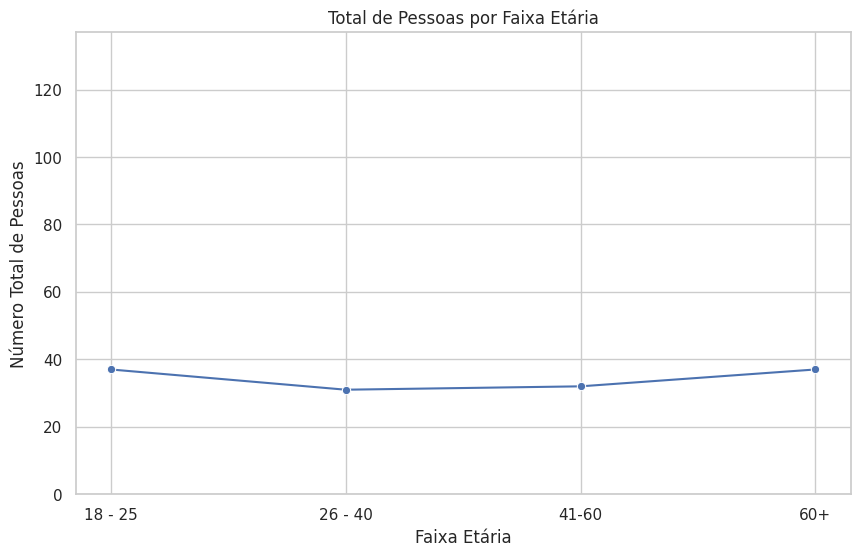

In [172]:
total_por_faixa = df_limpo.groupby('faixa_etaria').size().reset_index(name='quantidade')

plt.figure(figsize=(10,6))
sns.lineplot(data=total_por_faixa, x='faixa_etaria', y='quantidade', marker='o')
plt.title('Total de Pessoas por Faixa Etária')
plt.xlabel('Faixa Etária')
plt.ylabel('Número Total de Pessoas')
plt.ylim(0, df_limpo.shape[0])
plt.show()

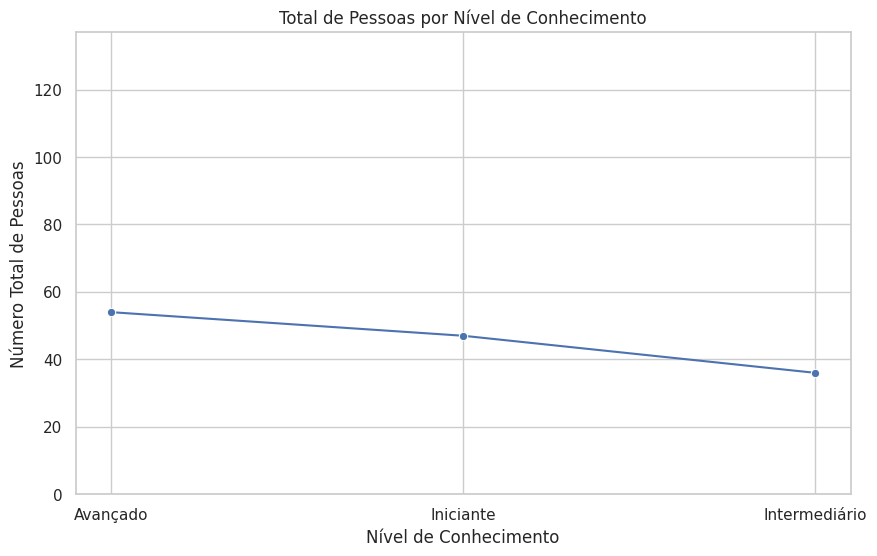

In [173]:
total_por_nivel = df_limpo.groupby('nivel_conhecimento').size().reset_index(name='quantidade')

plt.figure(figsize=(10,6))
sns.lineplot(data=total_por_nivel, x='nivel_conhecimento', y='quantidade', marker='o')
plt.title('Total de Pessoas por Nível de Conhecimento')
plt.xlabel('Nível de Conhecimento')
plt.ylabel('Número Total de Pessoas')
plt.ylim(0, df_limpo.shape[0])
plt.show()


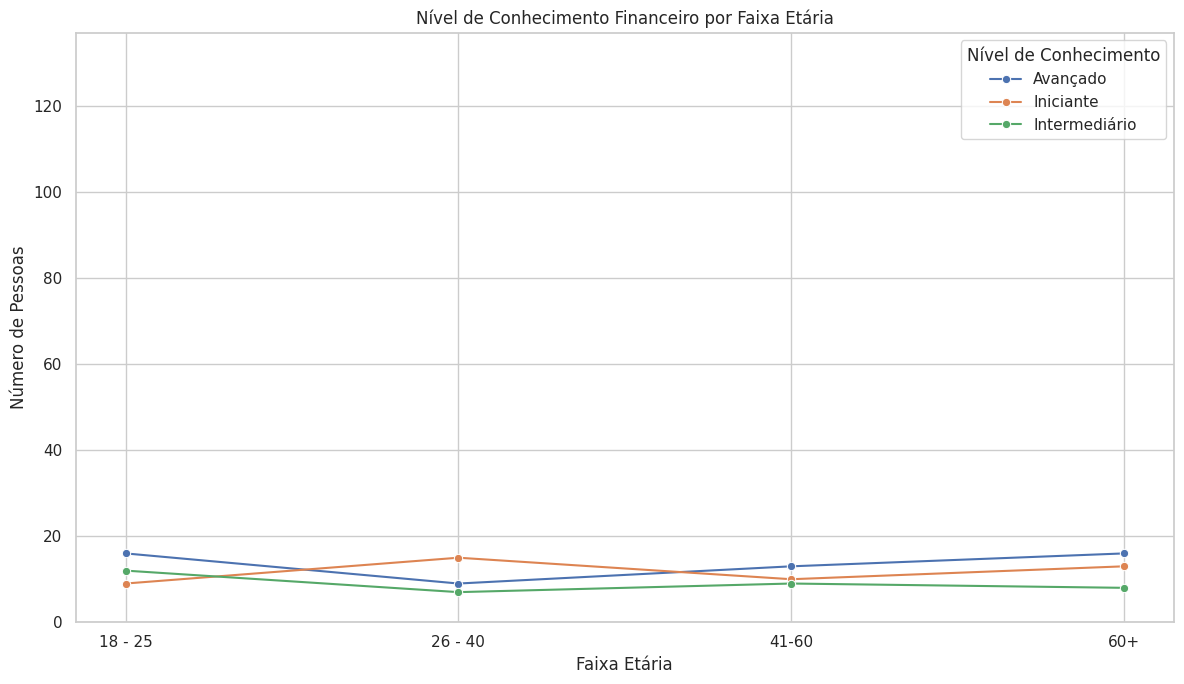

In [174]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams['figure.figsize'] = (12, 7)

df_limpo['faixa_etaria'] = df_limpo['faixa_etaria'].str.strip()
df_limpo['nivel_conhecimento'] = df_limpo['nivel_conhecimento'].str.strip().str.title()

conhecimento_por_faixa = (
    df_limpo.groupby(['faixa_etaria', 'nivel_conhecimento'])
    .size()
    .reset_index(name='quantidade')
)

plt.figure(figsize=(12, 7))
sns.lineplot(
    data=conhecimento_por_faixa,
    x='faixa_etaria',
    y='quantidade',
    hue='nivel_conhecimento',
    marker='o'
)

plt.title('Nível de Conhecimento Financeiro por Faixa Etária')
plt.xlabel('Faixa Etária')
plt.ylabel('Número de Pessoas')
plt.ylim(0, df_limpo.shape[0])
plt.legend(title='Nível de Conhecimento')
plt.tight_layout()
plt.show()


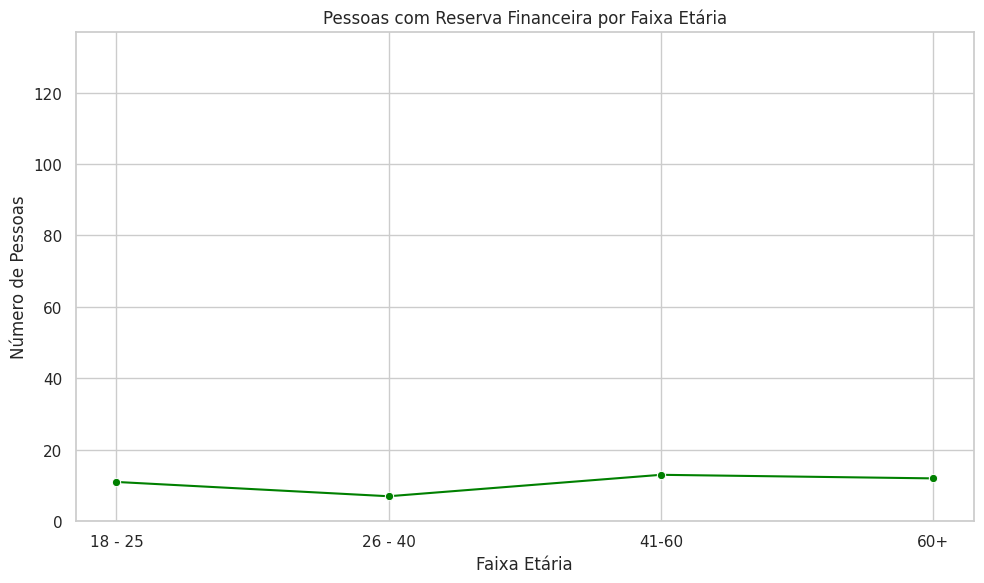

In [175]:
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams['figure.figsize'] = (10, 6)

reserva_por_faixa = df_limpo.groupby(['faixa_etaria']).agg(
    pessoas_com_reserva=('reserva_financeira', lambda x: (x == 'Sim').sum())
).reset_index()

plt.figure(figsize=(10,6))
sns.lineplot(
    data=reserva_por_faixa,
    x='faixa_etaria',
    y='pessoas_com_reserva',
    marker='o',
    color='green'
)
plt.title('Pessoas com Reserva Financeira por Faixa Etária')
plt.xlabel('Faixa Etária')
plt.ylabel('Número de Pessoas')
plt.ylim(0, df_limpo.shape[0])
plt.tight_layout()
plt.show()


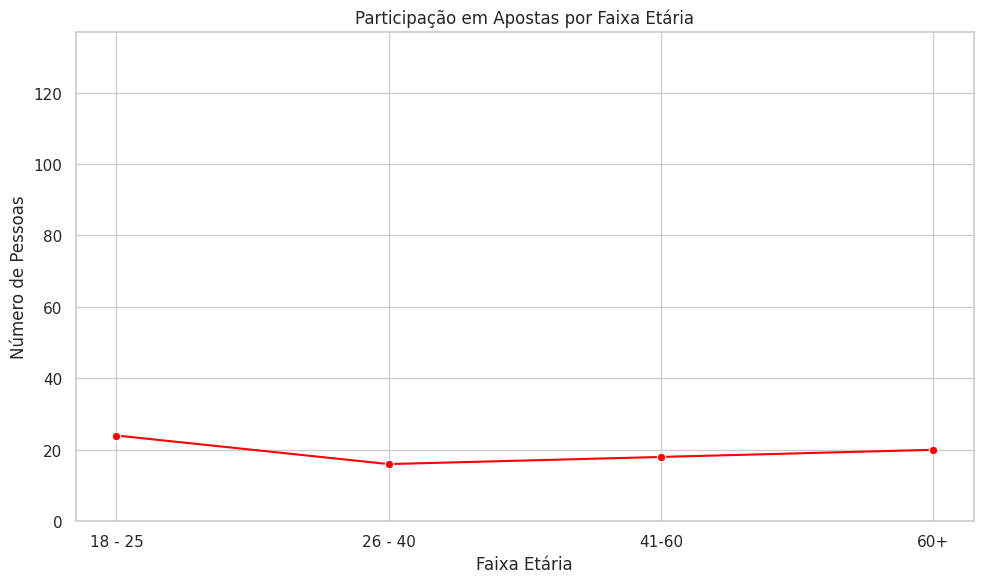

In [176]:
apostas_por_faixa = df_limpo.groupby('faixa_etaria').agg(
    pessoas_que_apostam=('participa_apostas', lambda x: x.str.contains('Sim').sum())
).reset_index()

plt.figure(figsize=(10,6))
sns.lineplot(
    data=apostas_por_faixa,
    x='faixa_etaria',
    y='pessoas_que_apostam',
    marker='o',
    color='red'
)
plt.title('Participação em Apostas por Faixa Etária')
plt.xlabel('Faixa Etária')
plt.ylabel('Número de Pessoas')
plt.ylim(0, df_limpo.shape[0])
plt.tight_layout()
plt.show()


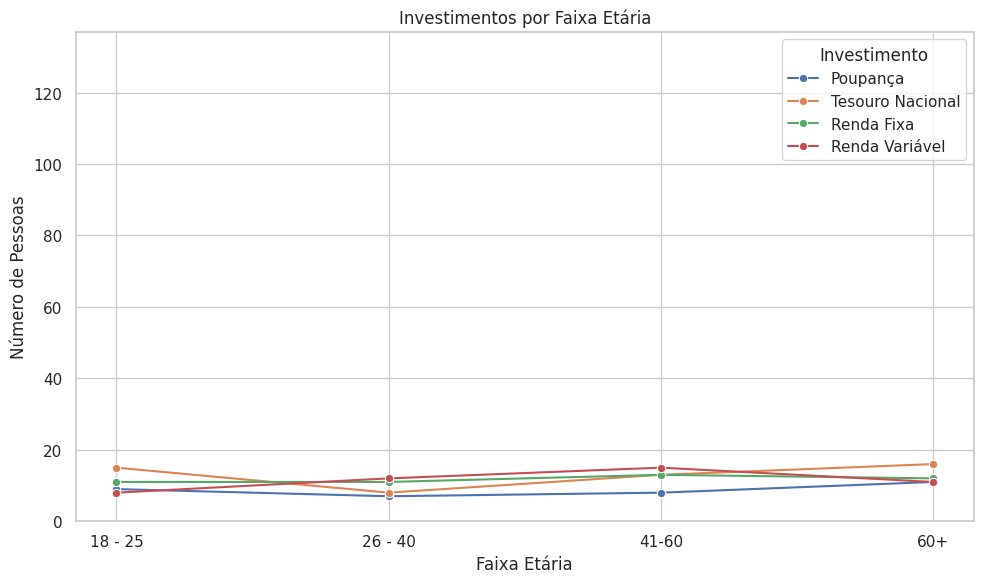

In [177]:
investimentos_por_faixa = df_limpo.groupby('faixa_etaria').agg(
    poupanca=('poupanca', lambda x: (x == 'Sim').sum()),
    tesouro=('tesouro', lambda x: (x == 'Sim').sum()),
    renda_fixa=('renda_fixa', lambda x: (x == 'Sim').sum()),
    renda_variavel=('renda_variavel', lambda x: (x == 'Sim').sum())
).reset_index()

plt.figure(figsize=(10,6))
sns.lineplot(data=investimentos_por_faixa, x='faixa_etaria', y='poupanca', marker='o', label='Poupança')
sns.lineplot(data=investimentos_por_faixa, x='faixa_etaria', y='tesouro', marker='o', label='Tesouro Nacional')
sns.lineplot(data=investimentos_por_faixa, x='faixa_etaria', y='renda_fixa', marker='o', label='Renda Fixa')
sns.lineplot(data=investimentos_por_faixa, x='faixa_etaria', y='renda_variavel', marker='o', label='Renda Variável')

plt.title('Investimentos por Faixa Etária')
plt.xlabel('Faixa Etária')
plt.ylabel('Número de Pessoas')
plt.ylim(0, df_limpo.shape[0])
plt.legend(title='Investimento')
plt.tight_layout()
plt.show()



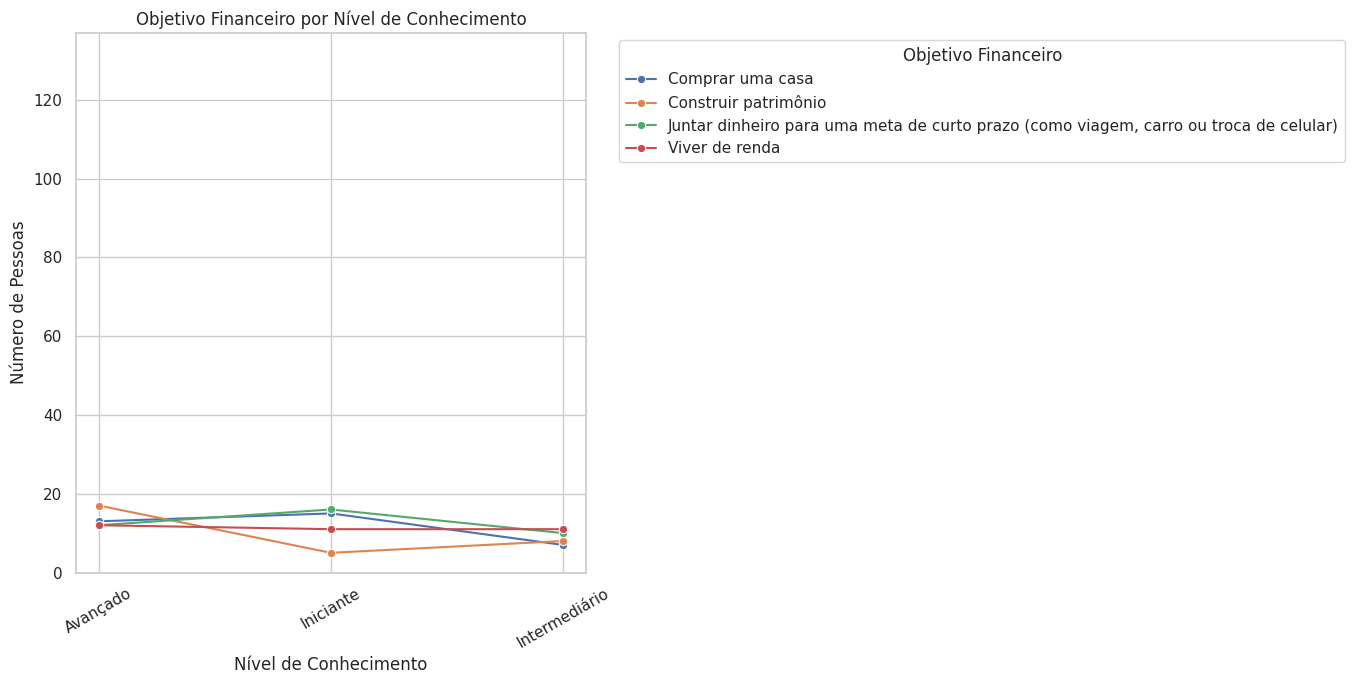

In [179]:
plt.figure(figsize=(14,7))  # Aumenta a largura

sns.lineplot(
    data=conhecimento_objetivo,
    x='nivel_conhecimento',
    y='quantidade',
    hue='objetivo_financeiro',
    marker='o'
)

plt.title('Objetivo Financeiro por Nível de Conhecimento')
plt.xlabel('Nível de Conhecimento')
plt.ylabel('Número de Pessoas')

plt.xticks(rotation=30)  # Rotaciona os rótulos para melhor leitura
plt.ylim(0, df_limpo.shape[0])

plt.legend(title='Objetivo Financeiro', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()  # Ajusta o layout para não cortar elementos
plt.show()


<Figure size 1200x600 with 0 Axes>

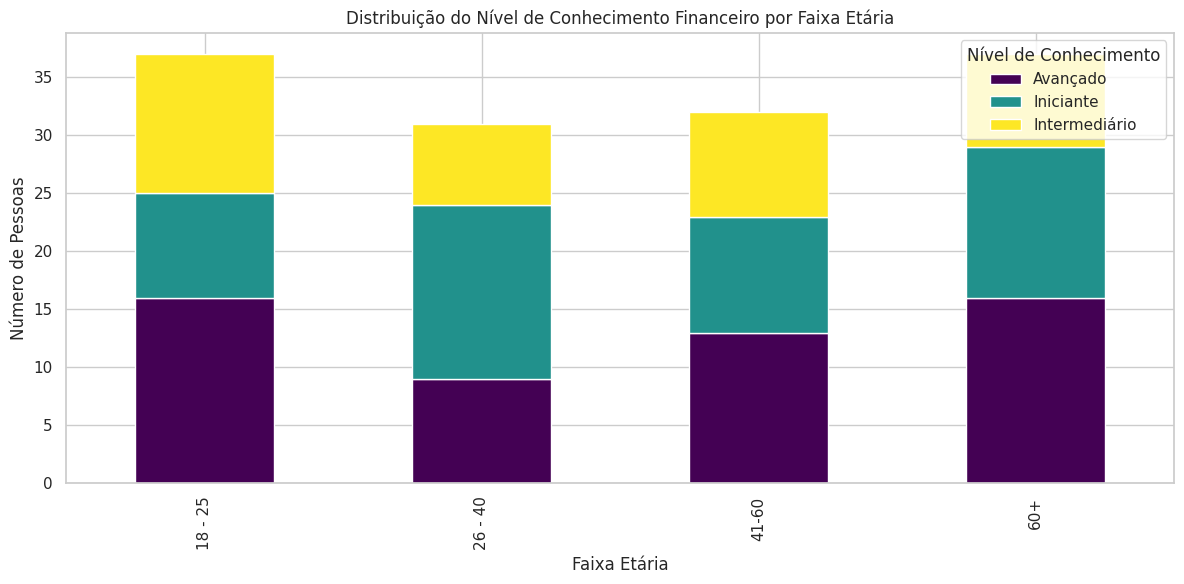

In [180]:
plt.figure(figsize=(12,6))
conhecimento_idade = df_limpo.groupby(['faixa_etaria', 'nivel_conhecimento']).size().reset_index(name='quantidade')
conhecimento_pivot = conhecimento_idade.pivot(index='faixa_etaria', columns='nivel_conhecimento', values='quantidade').fillna(0)

conhecimento_pivot.plot(kind='bar', stacked=True, figsize=(12,6), colormap='viridis')

plt.title('Distribuição do Nível de Conhecimento Financeiro por Faixa Etária')
plt.xlabel('Faixa Etária')
plt.ylabel('Número de Pessoas')
plt.legend(title='Nível de Conhecimento')
plt.tight_layout()
plt.show()


/tmp/ipython-input-2838818012.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=reserva_por_nivel, x='nivel_conhecimento', y='reserva_financeira', palette='coolwarm')


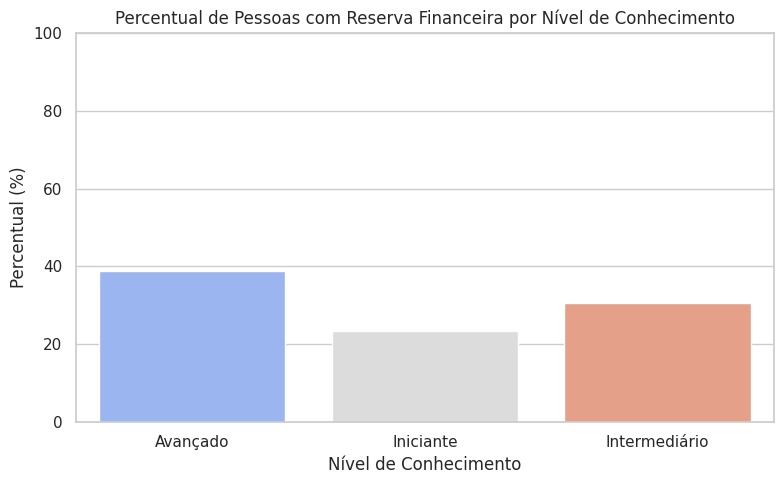

In [181]:
reserva_por_nivel = df_limpo.groupby('nivel_conhecimento')['reserva_financeira'].apply(lambda x: (x == 'Sim').mean() * 100).reset_index()

plt.figure(figsize=(8,5))
sns.barplot(data=reserva_por_nivel, x='nivel_conhecimento', y='reserva_financeira', palette='coolwarm')

plt.title('Percentual de Pessoas com Reserva Financeira por Nível de Conhecimento')
plt.xlabel('Nível de Conhecimento')
plt.ylabel('Percentual (%)')
plt.ylim(0, 100)
plt.tight_layout()
plt.show()


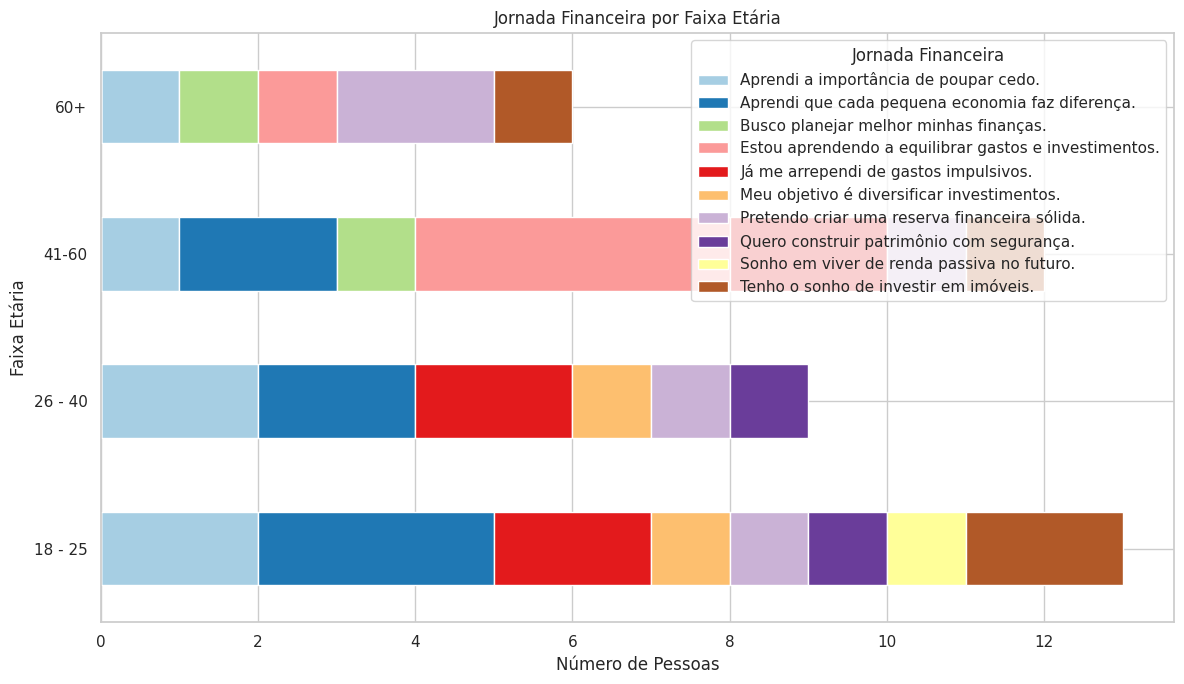

In [182]:
jornada_idade = df_limpo.groupby(['faixa_etaria', 'jornada_financeira']).size().reset_index(name='quantidade')
jornada_pivot = jornada_idade.pivot(index='faixa_etaria', columns='jornada_financeira', values='quantidade').fillna(0)

jornada_pivot.plot(kind='barh', stacked=True, figsize=(12,7), colormap='Paired')

plt.title('Jornada Financeira por Faixa Etária')
plt.xlabel('Número de Pessoas')
plt.ylabel('Faixa Etária')
plt.legend(title='Jornada Financeira')
plt.tight_layout()
plt.show()


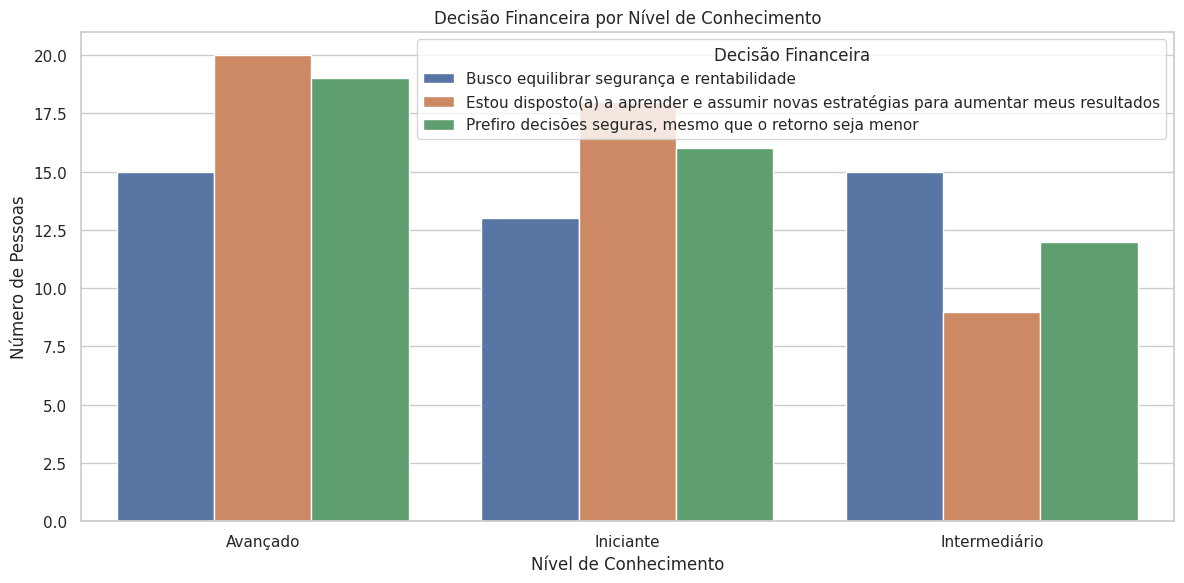

In [183]:
decisao_conhecimento = df_limpo.groupby(['nivel_conhecimento', 'decisao_financeira']).size().reset_index(name='quantidade')

plt.figure(figsize=(12,6))
sns.barplot(data=decisao_conhecimento, x='nivel_conhecimento', y='quantidade', hue='decisao_financeira')

plt.title('Decisão Financeira por Nível de Conhecimento')
plt.xlabel('Nível de Conhecimento')
plt.ylabel('Número de Pessoas')
plt.legend(title='Decisão Financeira')
plt.tight_layout()
plt.show()
